In [1]:
import pandas as pd
import numpy as np
import ast

import folium
from folium.plugins import HeatMap

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")

print(df.shape)
print(df.head())

(298450, 24)
           id   latitude  longitude  \
0  FKID000000  12.925557  77.618665   
1  FKID000001  12.905463  77.700778   
2  FKID000002  12.925449  77.618504   
3  FKID000003  12.956521  77.518618   
4  FKID000004  12.977767  77.580545   

                                            location vehicle_number  \
0  18th Main Road, Block 2, Koramangala, Bengalur...    FKN00GL0000   
1  Sarjapura Main Road, The Grove, Janatha Colony...    FKN00GL0001   
2  Koramangala 2nd Block, Kormangala West, Bengal...    FKN00GL0002   
3  6th Cross Road, Manasa Layout, Nagarbhavi, Ben...    FKN00GL0003   
4  Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...    FKN00GL0004   

  vehicle_type  description                                  violation_type  \
0          CAR          NaN  ["WRONG PARKING","PARKING NEAR ROAD CROSSING"]   
1          CAR          NaN                                  ["NO PARKING"]   
2          CAR          NaN      ["WRONG PARKING","PARKING IN A MAIN ROAD"]   
3      SC

In [3]:
def parse_violation(x):

    if isinstance(x, list):
        return x

    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return [x]

    return []

df["violation_type"] = df["violation_type"].apply(
    parse_violation
)

print(df["violation_type"].iloc[0])

['WRONG PARKING', 'PARKING NEAR ROAD CROSSING']


In [5]:
parking_df = df[
    df["violation_type"].apply(
        lambda x: any(
            "PARK" in v.upper()
            for v in x
        )
    )
].copy()

print(parking_df.shape)

(298450, 24)


In [6]:
parking_df["created_datetime"] = pd.to_datetime(
    parking_df["created_datetime"],
    format="mixed",
    utc=True
)

parking_df["created_datetime"] = (
    parking_df["created_datetime"]
    .dt.tz_convert("Asia/Kolkata")
)

parking_df["hour"] = (
    parking_df["created_datetime"]
    .dt.hour
)

parking_df["date"] = (
    parking_df["created_datetime"]
    .dt.date
)

In [7]:
m = folium.Map(
    location=[
        parking_df["latitude"].mean(),
        parking_df["longitude"].mean()
    ],
    zoom_start=11
)

HeatMap(
    parking_df[
        ["latitude", "longitude"]
    ].values.tolist(),
    radius=12
).add_to(m)

m.save("parking_heatmap.html")

In [ ]:

coords = np.radians(
    parking_df[["latitude","longitude"]]
)

kms_per_radian = 6371.0088

epsilon = 0.15 / kms_per_radian

db = DBSCAN(
    eps=epsilon,
    min_samples=50,
    metric="haversine"
)

parking_df["cluster"] = db.fit_predict(coords)

In [9]:
cluster_rank = (
    parking_df[
        parking_df["cluster"] != -1
    ]
    .groupby("cluster")
    .size()
    .reset_index(name="violations")
    .sort_values(
        "violations",
        ascending=False
    )
)

print(cluster_rank.head(20))

     cluster  violations
2          2       58958
3          3       25376
5          5       14746
31        31       10289
10        10       10208
32        32       10078
62        62        9007
56        56        6127
24        24        4765
28        28        4739
16        16        4374
7          7        4170
40        40        3478
18        18        2996
26        26        2823
96        96        2776
87        87        2258
33        33        2238
105      105        2173
23        23        2093


In [10]:
cluster_centers = (
    parking_df[
        parking_df["cluster"] != -1
    ]
    .groupby("cluster")
    [["latitude", "longitude"]]
    .mean()
    .reset_index()
)

cluster_summary = (
    cluster_centers
    .merge(
        cluster_rank,
        on="cluster"
    )
)

print(cluster_summary.head())

   cluster   latitude  longitude  violations
0        0  12.925240  77.618847         593
1        1  12.957320  77.518809         511
2        2  12.971972  77.577592       58958
3        3  12.981966  77.608017       25376
4        4  12.995571  77.612820        1997


In [11]:
cluster_junction = (
    parking_df[
        parking_df["cluster"] != -1
    ]
    .groupby("cluster")["junction_name"]
    .agg(
        lambda x:
        x.mode().iloc[0]
        if not x.mode().empty
        else "Unknown"
    )
    .reset_index()
)

cluster_summary = (
    cluster_summary
    .merge(
        cluster_junction,
        on="cluster",
        how="left"
    )
)

In [12]:
cluster_hourly = (
    parking_df[
        parking_df["cluster"] != -1
    ]
    .groupby(
        ["cluster", "hour"]
    )
    .size()
    .reset_index(name="count")
)

peak_hours = (
    cluster_hourly
    .sort_values(
        "count",
        ascending=False
    )
    .groupby("cluster")
    .first()
    .reset_index()
)

In [14]:
final_table = (
    cluster_summary
    .merge(
        peak_hours[
            ["cluster", "hour", "count"]
        ],
        on="cluster",
        how="left"
    )
)

final_table["peak_time"] = (
    final_table["hour"]
    .apply(
        lambda h:
        f"{h:02d}:00 - {(h+1)%24:02d}:00"
    )
)

In [15]:
cluster_violation_type = (
    parking_df
    .explode("violation_type")
    .groupby("cluster")["violation_type"]
    .agg(
        lambda x:
        x.mode().iloc[0]
    )
    .reset_index()
)

cluster_violation_type.rename(
    columns={
        "violation_type":
        "dominant_violation"
    },
    inplace=True
)

final_table = (
    final_table
    .merge(
        cluster_violation_type,
        on="cluster"
    )
)

In [16]:
cluster_station = (
    parking_df
    .groupby("cluster")["police_station"]
    .agg(
        lambda x:
        x.mode().iloc[0]
    )
    .reset_index()
)

cluster_station.rename(
    columns={
        "police_station":
        "assigned_station"
    },
    inplace=True
)

final_table = (
    final_table
    .merge(
        cluster_station,
        on="cluster"
    )
)

In [17]:
viol_expanded = (
    parking_df[
        parking_df["cluster"] != -1
    ]
    .explode("violation_type")
)

total_violations = (
    parking_df[
        parking_df["cluster"] != -1
    ]
    .groupby("cluster")
    .size()
    .rename("total_violations")
)

mainroad_ratio = (
    viol_expanded
    .assign(
        mainroad=lambda x:
        (
            x["violation_type"]
            ==
            "PARKING IN A MAIN ROAD"
        ).astype(int)
    )
    .groupby("cluster")["mainroad"]
    .mean()
    .rename("mainroad_ratio")
)

double_ratio = (
    viol_expanded
    .assign(
        double=lambda x:
        (
            x["violation_type"]
            ==
            "DOUBLE PARKING"
        ).astype(int)
    )
    .groupby("cluster")["double"]
    .mean()
    .rename("double_ratio")
)

junction_ratio = (
    parking_df[
        parking_df["cluster"] != -1
    ]
    .assign(
        junction=lambda x:
        (
            x["junction_name"]
            != "No Junction"
        ).astype(int)
    )
    .groupby("cluster")["junction"]
    .mean()
    .rename("junction_ratio")
)

peak_fraction = []

for cluster in (
    parking_df[
        parking_df["cluster"] != -1
    ]["cluster"]
    .unique()
):

    temp = cluster_hourly[
        cluster_hourly["cluster"]
        == cluster
    ]

    peak = temp["count"].max()
    total = temp["count"].sum()

    peak_fraction.append(
        [cluster, peak / total]
    )

peak_fraction = pd.DataFrame(
    peak_fraction,
    columns=[
        "cluster",
        "peak_fraction"
    ]
)

active_days = (
    parking_df[
        parking_df["cluster"] != -1
    ]
    .groupby("cluster")["date"]
    .nunique()
    .rename("active_days")
)

In [ ]:
cluster_features = pd.concat(
    [
        total_violations,
        mainroad_ratio,
        double_ratio,
        junction_ratio,
        active_days
    ],
    axis=1
).reset_index()

cluster_features = (
    cluster_features
    .merge(
        peak_fraction,
        on="cluster"
    )
)

In [19]:
feature_cols = [
    "total_violations",
    "mainroad_ratio",
    "double_ratio",
    "junction_ratio",
    "active_days",
    "peak_fraction"
]

scaler = MinMaxScaler()

cluster_features[
    feature_cols
] = scaler.fit_transform(
    cluster_features[
        feature_cols
    ]
)

In [ ]:
cluster_features["severity"] = (
      0.40 * cluster_features["junction_ratio"]
    + 0.30 * cluster_features["mainroad_ratio"]
    + 0.15 * cluster_features["double_ratio"]
    + 0.10 * cluster_features["peak_fraction"]
    + 0.05 * cluster_features["active_days"]
)
cluster_features["exposure"] = (
    cluster_features["total_violations"]
    - cluster_features["total_violations"].min()
) / (
    cluster_features["total_violations"].max()
    - cluster_features["total_violations"].min()
)

cluster_features["PICRI"] = (
    (
        0.6 * cluster_features["exposure"]
        +
        0.4 * cluster_features["severity"]
    )
    * 100
)

In [ ]:
def risk(score):

    if score >= 75:
        return "High"

    elif score >= 50:
        return "Medium"

    else:
        return "Low"


cluster_features["risk_level"] = (
    cluster_features["PICRI"]
    .apply(risk)
)

In [ ]:
cluster_features = (
    cluster_features
    .sort_values(
        "PICRI",
        ascending=False
    )
)

print(
    cluster_features[
        [
            "cluster",
            "total_violations",
            "severity",
            "exposure",
            "PICRI",
            "risk_level"
        ]
    ].head(20)
)

     cluster  total_violations  mainroad_ratio  double_ratio  junction_ratio  \
2          2          1.000000        0.053411      0.021226        0.978917   
47        47          0.005465        0.106122      0.845201        0.997222   
3          3          0.430041        0.040068      0.089425        0.813761   
107      107          0.003360        0.699454      0.000000        0.915254   
44        44          0.002902        0.647975      0.000000        1.000000   
148      148          0.003632        0.629032      0.000000        1.000000   
291      291          0.000339        0.341463      0.561177        1.000000   
5          5          0.249627        0.052086      0.009540        1.000000   
176      176          0.000339        0.686869      0.278888        1.000000   
62        62          0.152223        0.023730      0.032855        0.976574   
73        73          0.028208        0.225121      0.044460        1.000000   
33        33          0.037339        0.

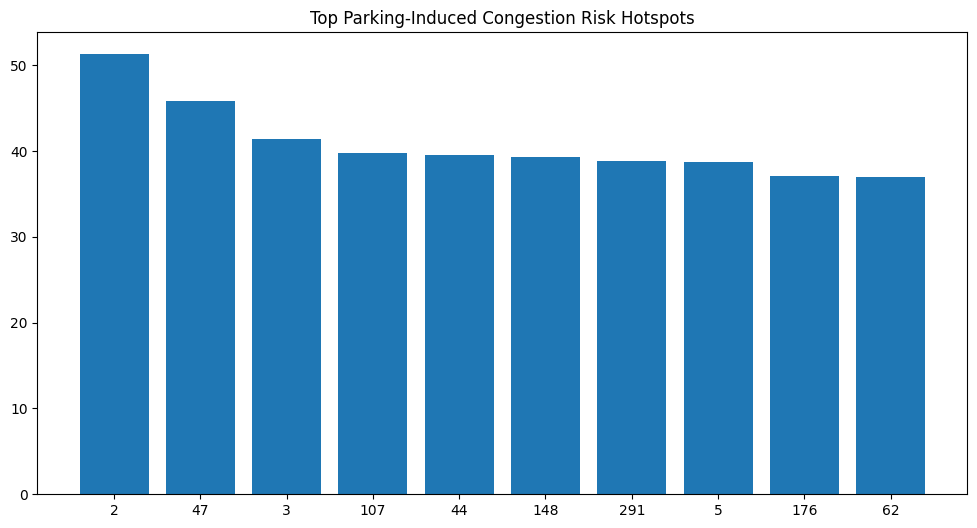

In [23]:
top10 = (
    cluster_features
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top10["cluster"].astype(str),
    top10["PICRI"]
)

plt.title(
    "Top Parking-Induced Congestion Risk Hotspots"
)

plt.show()

In [ ]:
final_table.to_csv("final_table.csv", index=False)
cluster_features.to_csv("cluster_features.csv", index=False)

print("Saved final_table.csv and cluster_features.csv")